In [1]:
#IMPORT DATASET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import math

In [2]:
df = pd.read_csv("train.csv")
df

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,C-43723,Angelyn Clevenger,M,38,4969.41,Low,Commercial associate,Managers,Urban,76657.90,...,869.61,0,Unpossessed,566,4969.41,4,Urban,1,111096.56,68992.11
29996,C-32511,Silas Slaugh,M,20,1606.88,Low,Working,Laborers,Semi-Urban,66595.14,...,729.41,0,Inactive,175,1606.88,3,Urban,1,73453.94,46616.60
29997,C-5192,Carmelo Lone,F,49,NaN,Low,Working,Sales staff,Urban,81410.08,...,NaN,0,Active,959,NaN,1,Rural,1,102108.02,61057.56
29998,C-12172,Carolann Osby,M,38,2417.71,Low,Working,Security staff,Semi-Urban,142524.10,...,677.27,1,Unpossessed,375,2417.71,4,Urban,1,168194.47,99766.87


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  object 
 13  Dependents      

In [4]:
df.describe()

print("Shape:", df.shape)
print("\nHead:\n", df.head())

Shape: (30000, 24)

Head:
   Customer ID               Name Gender  Age  Income (USD) Income Stability  \
0     C-36995   Frederica Shealy      F   56       1933.05              Low   
1     C-33999  America Calderone      M   32       4952.91              Low   
2      C-3770      Rosetta Verne      F   65        988.19             High   
3     C-26480         Zoe Chitty      F   65           NaN             High   
4     C-23459       Afton Venema      F   31       2614.77              Low   

  Profession     Type of Employment    Location  Loan Amount Request (USD)  \
0    Working            Sales staff  Semi-Urban                   72809.58   
1    Working                    NaN  Semi-Urban                   46837.47   
2  Pensioner                    NaN  Semi-Urban                   45593.04   
3  Pensioner                    NaN       Rural                   80057.92   
4    Working  High skill tech staff  Semi-Urban                  113858.89   

   ...  Credit Score No. of D

In [5]:
#EXPLORATORY DATA ANALYSIS: FIND MISSING VALUES AND CORRECT THEM: 


In [6]:
missing_count = df.isna().sum()
missing_count = missing_count[missing_count > 0].sort_values(ascending=False)

missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
})

print("\n=== Columns with missing values (sorted) ===")
print(missing_summary)

print("\n=== Top columns with most missing values ===")
print(missing_summary.head(10))


=== Columns with missing values (sorted) ===
                             missing_count  missing_pct
Type of Employment                    7270        24.23
Property Age                          4850        16.17
Income (USD)                          4576        15.25
Dependents                            2493         8.31
Credit Score                          1703         5.68
Income Stability                      1683         5.61
Has Active Credit Card                1566         5.22
Property Location                      356         1.19
Loan Sanction Amount (USD)             340         1.13
Current Loan Expenses (USD)            172         0.57
Gender                                  53         0.18

=== Top columns with most missing values ===
                             missing_count  missing_pct
Type of Employment                    7270        24.23
Property Age                          4850        16.17
Income (USD)                          4576        15.25
Dependents  

In [7]:
df = df[df.Gender.notnull()]
df = df[df["Property Location"].notnull()]
df = df[df["Loan Sanction Amount (USD)"].notnull()]
df = df[df["Current Loan Expenses (USD)"].notnull()]
print(df.shape)

(29097, 24)


In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\n=== Column Types ===")
print("Numeric columns:", numeric_cols)
print("Categorical/bool columns:", cat_cols)


=== Column Types ===
Numeric columns: ['Age', 'Income (USD)', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property ID', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']
Categorical/bool columns: ['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location']


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


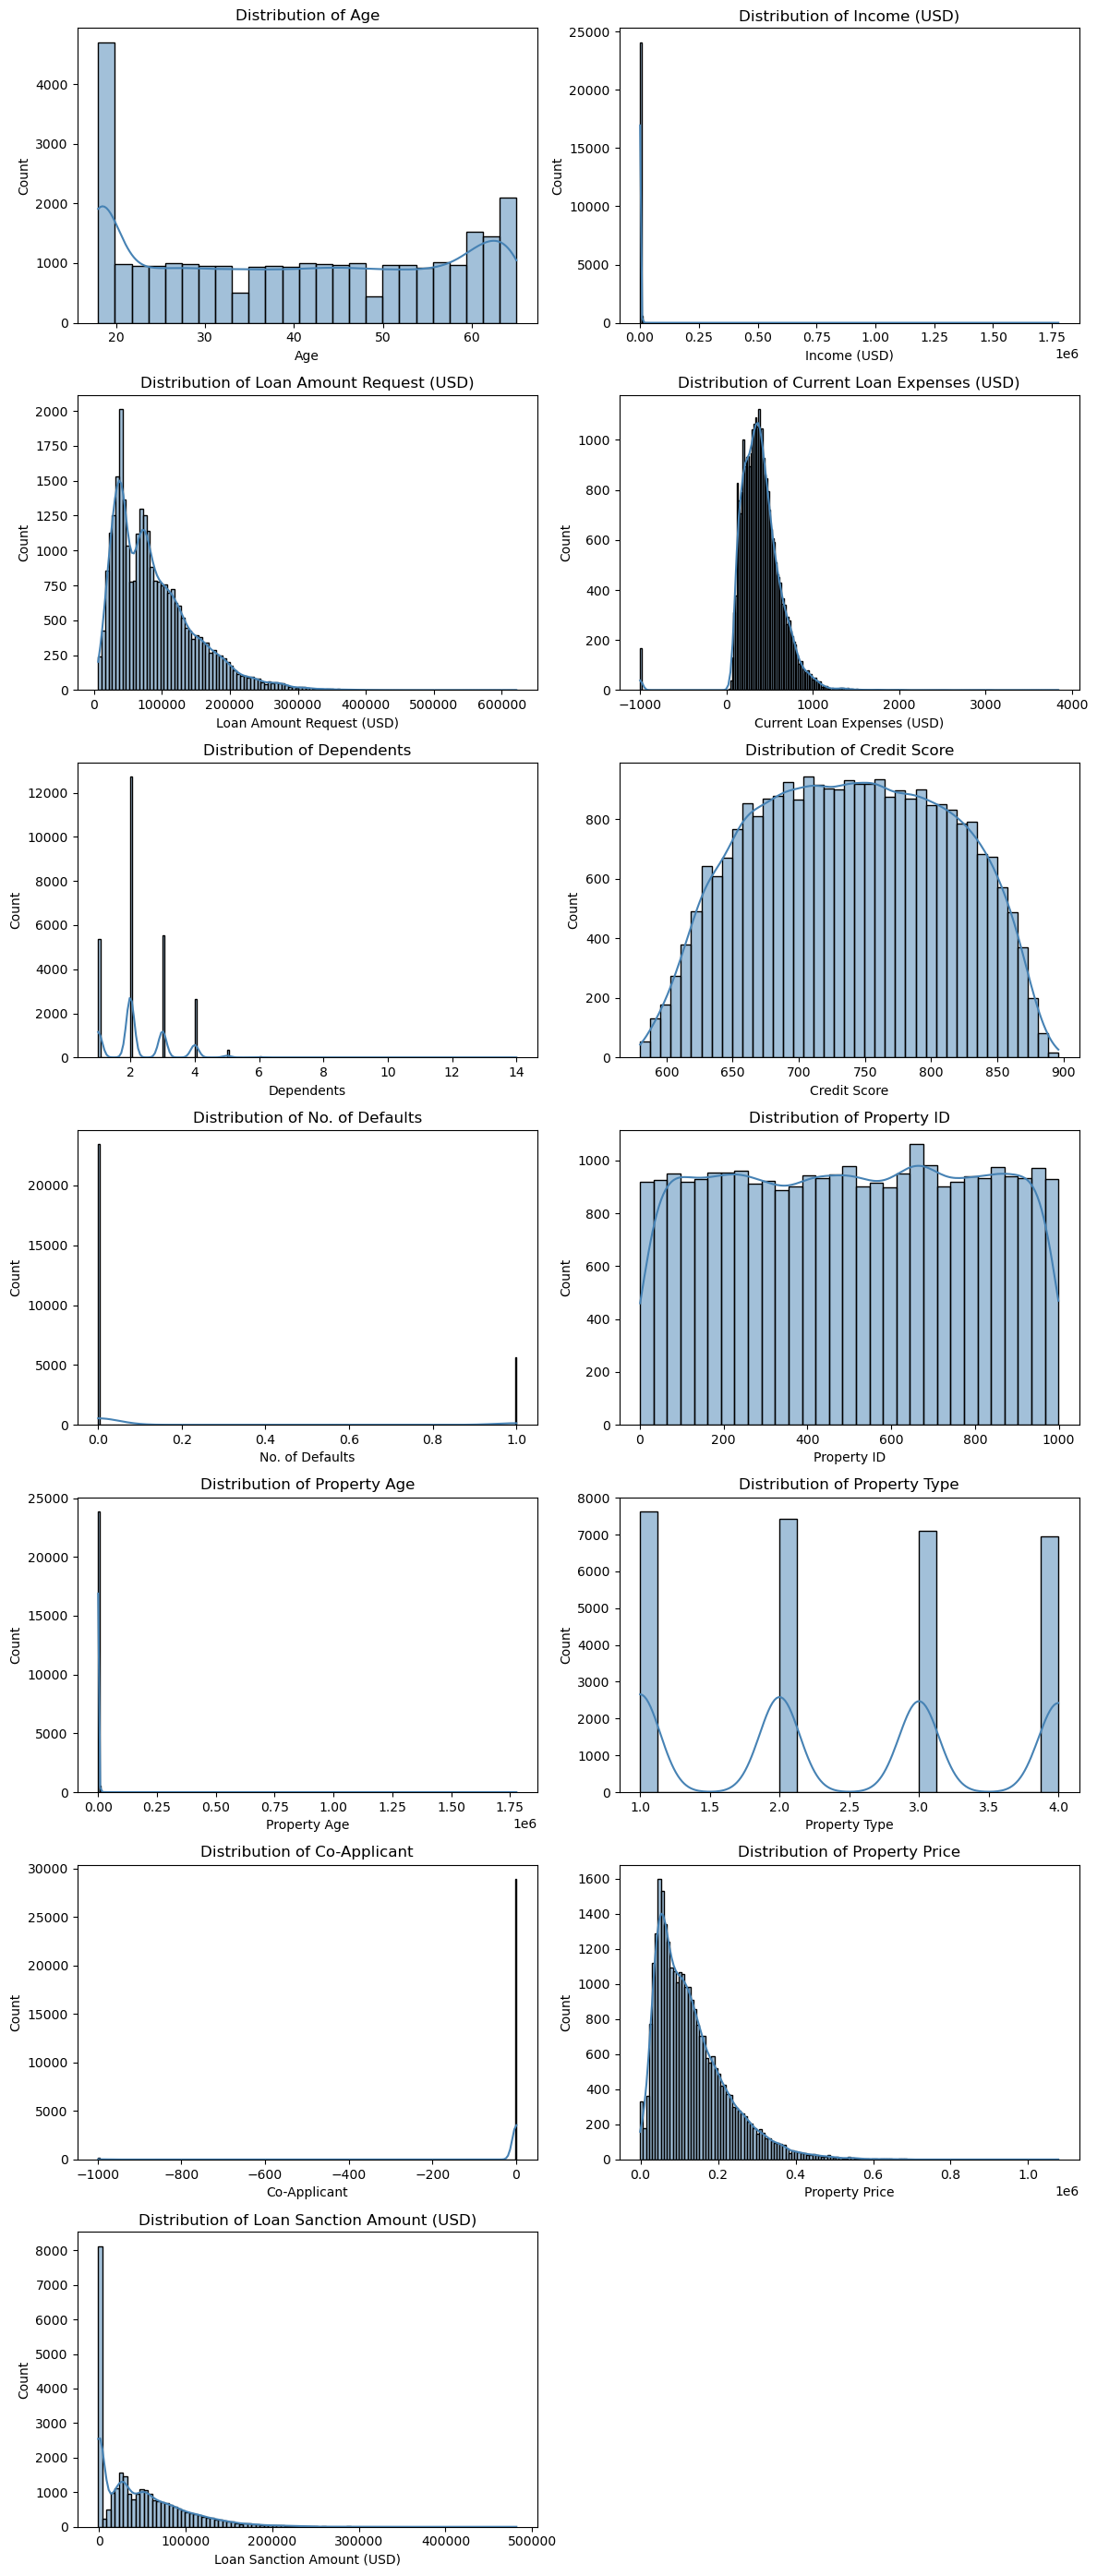

In [9]:
#Hencce there are missing values present.
cols = 2
rows = (len(numeric_cols) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue", linewidth=1)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
# hide unused axes
for j in range(i+1, len(axes)):
    try:
        fig.delaxes(axes[j])
    except Exception:
        pass
plt.tight_layout()
plt.savefig( "assign3_1.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

In [10]:
print("\nMissing values per column (top 10):\n", df.isna().sum().sort_values(ascending=False))


Missing values per column (top 10):
 Type of Employment             7047
Property Age                   4614
Income (USD)                   4358
Dependents                     2368
Credit Score                   1621
Income Stability               1601
Has Active Credit Card         1512
Customer ID                       0
Property Price                    0
Co-Applicant                      0
Property Location                 0
Property Type                     0
Property ID                       0
No. of Defaults                   0
Expense Type 2                    0
Name                              0
Expense Type 1                    0
Current Loan Expenses (USD)       0
Loan Amount Request (USD)         0
Location                          0
Profession                        0
Age                               0
Gender                            0
Loan Sanction Amount (USD)        0
dtype: int64


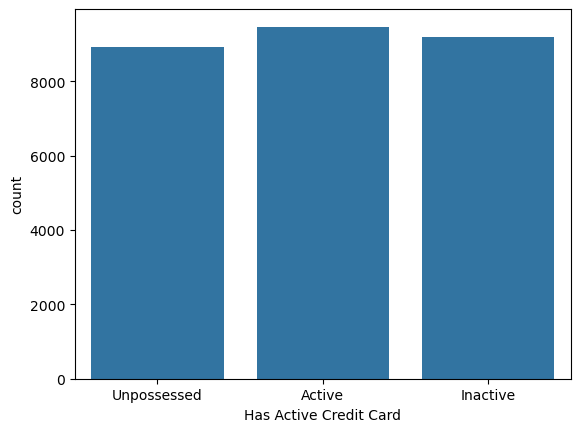

In [11]:
sns.countplot(x=df["Has Active Credit Card"])
plt.savefig( "assign3_2.eps", format="eps", dpi=600, bbox_inches="tight" )

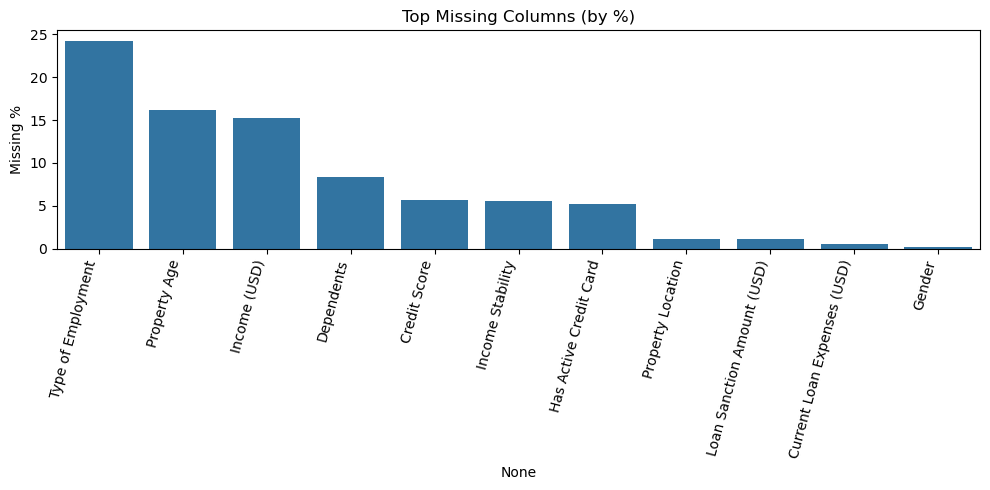

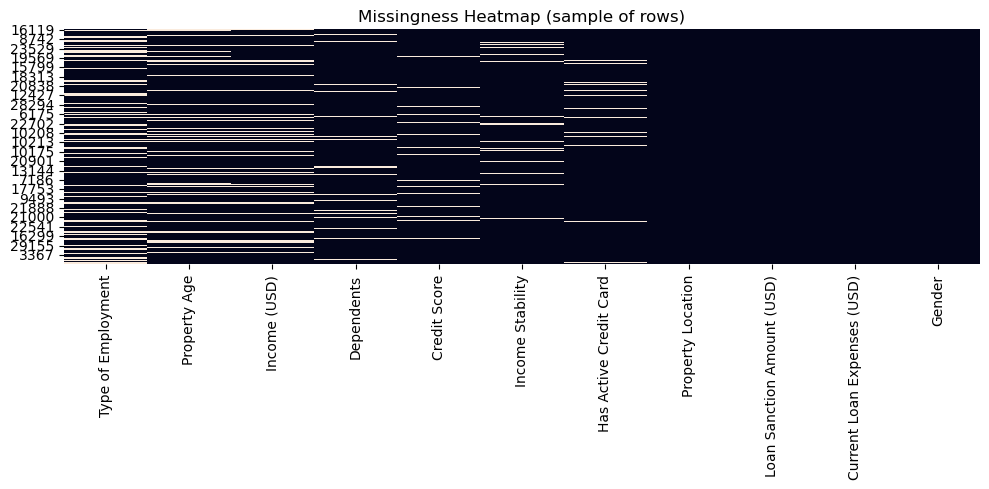

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=missing_summary.index[:15],
    y=missing_summary["missing_pct"].values[:15]
)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Missing %")
plt.title("Top Missing Columns (by %)")
plt.tight_layout()
plt.savefig( "assign3_3.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

# Heatmap (sample rows for readability)
sample_df = df[missing_summary.index].sample(min(300, len(df)), random_state=42)
plt.figure(figsize=(10, 5))
sns.heatmap(sample_df.isna(), cbar=False)
plt.title("Missingness Heatmap (sample of rows)")
plt.tight_layout()
plt.savefig( "assign3_4.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

In [13]:
df_imputed = df.copy()

# Identify numeric vs categorical
num_cols = df_imputed.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_imputed.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Only columns that actually have missing values
missing_cols = missing_summary.index.tolist()
num_missing_cols = [c for c in missing_cols if c in num_cols]
cat_missing_cols = [c for c in missing_cols if c in cat_cols]

print("\nNumeric columns with missing values:", num_missing_cols)
print("Categorical columns with missing values:", cat_missing_cols)



Numeric columns with missing values: ['Property Age', 'Income (USD)', 'Dependents', 'Credit Score', 'Loan Sanction Amount (USD)', 'Current Loan Expenses (USD)']
Categorical columns with missing values: ['Type of Employment', 'Income Stability', 'Has Active Credit Card', 'Property Location', 'Gender']


In [14]:
for col in num_missing_cols:
    mode_series = df_imputed[col].mode(dropna=True)
    if mode_series.empty:
        fill_val = 0
        reason = "all missing -> filled with 0"
    else:
        fill_val = mode_series.iloc[0]
        reason = f"mode = {fill_val}"
    df_imputed[col] = df_imputed[col].fillna(fill_val)
    print(f"[NUM] {col}: filled missing with {reason}")

for col in cat_missing_cols:
    
    df_imputed[col] = df_imputed[col].astype("string").str.strip()

    mode_series = df_imputed[col].mode(dropna=True)
    if mode_series.empty:
        fill_val = "Unknown"
        reason = 'all missing -> filled with "Unknown"'
    else:
        fill_val = mode_series.iloc[0]
        reason = f'most_frequent = "{fill_val}"'
    df_imputed[col] = df_imputed[col].fillna(fill_val)
    print(f"[CAT] {col}: filled missing with {reason}")

[NUM] Property Age: filled missing with mode = 1608.43
[NUM] Income (USD): filled missing with mode = 1608.43
[NUM] Dependents: filled missing with mode = 2.0
[NUM] Credit Score: filled missing with mode = 792.76
[NUM] Loan Sanction Amount (USD): filled missing with mode = 0.0
[NUM] Current Loan Expenses (USD): filled missing with mode = -999.0
[CAT] Type of Employment: filled missing with most_frequent = "Laborers"
[CAT] Income Stability: filled missing with most_frequent = "Low"
[CAT] Has Active Credit Card: filled missing with most_frequent = "Active"
[CAT] Property Location: filled missing with most_frequent = "Semi-Urban"
[CAT] Gender: filled missing with most_frequent = "M"


In [15]:
after_missing = df_imputed.isna().sum()
after_missing = after_missing[after_missing > 0].sort_values(ascending=False)

print("\n=== Missing values AFTER imputation ===")
if len(after_missing) == 0:
    print("No missing values remain")
else:
    print(after_missing)



=== Missing values AFTER imputation ===
No missing values remain


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


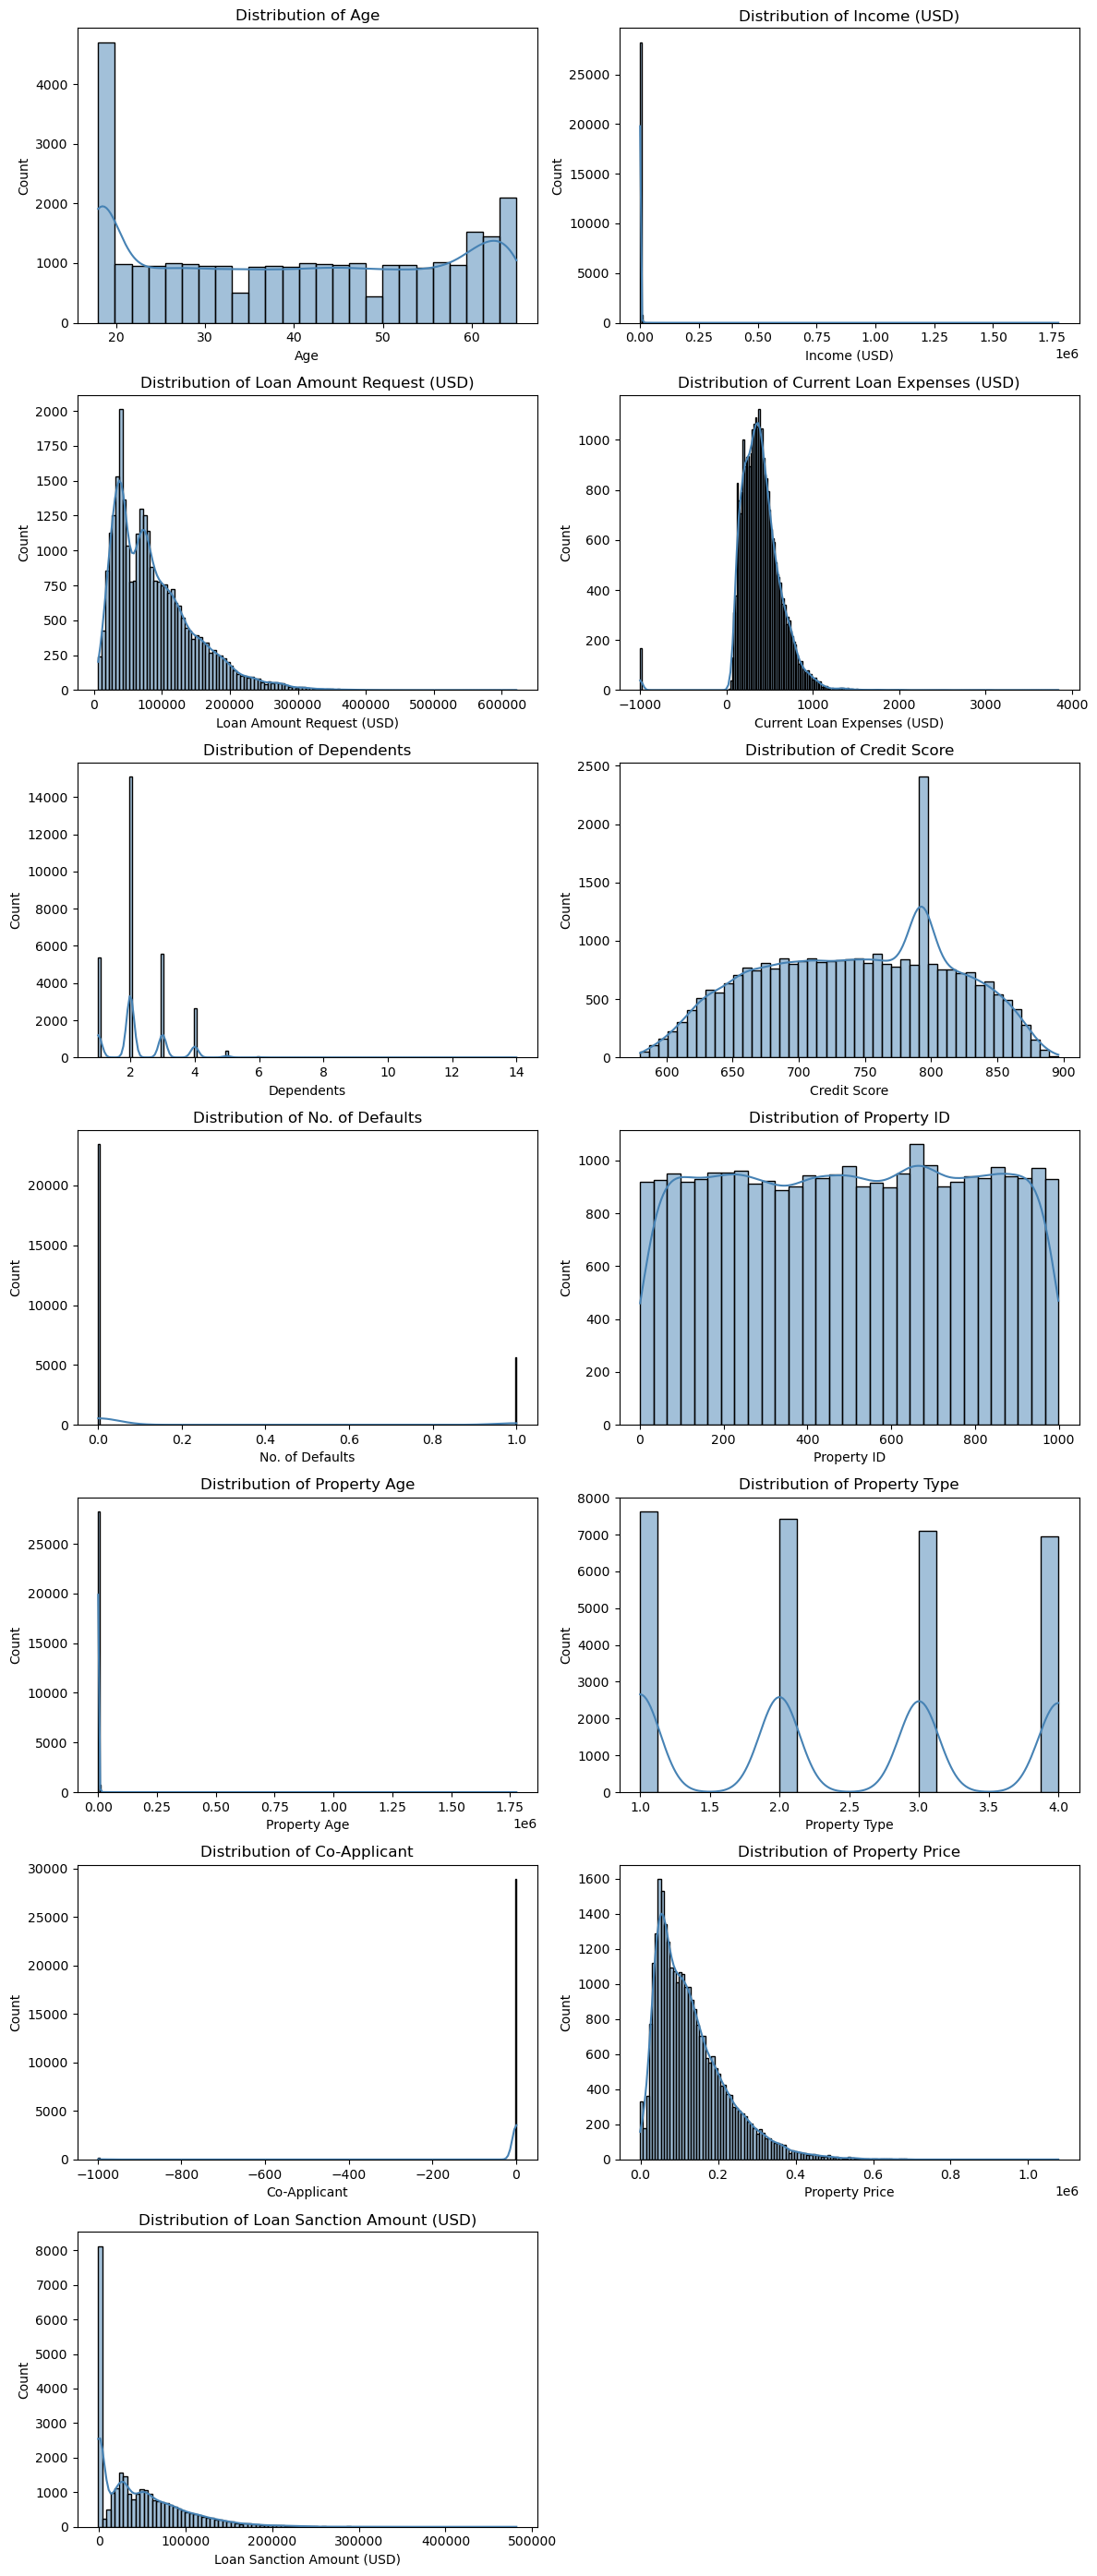

In [16]:
cols = 2
rows = (len(numeric_cols) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]
for i, col in enumerate(numeric_cols):
    sns.histplot(df_imputed[col], kde=True, ax=axes[i], color="steelblue", linewidth=1)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
# hide unused axes
for j in range(i+1, len(axes)):
    try:
        fig.delaxes(axes[j])
    except Exception:
        pass
plt.tight_layout()
plt.savefig( "assign3_5.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

In [17]:
#Now Dealing With OUTLIERS
df_iqr = df_imputed.copy()

In [18]:
#Now Dealing With OUTLIERS
new_numcol = set(num_cols) - {"No. of Defaults", "Co-Applicant"}
onehot = ["No. of Defaults","Co-Applicant"]
for col in new_numcol:
    Q1 = df_imputed[col].quantile(0.25)
    Q3 = df_imputed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before treatment
    outliers_before = ((df_iqr[col] < lower_bound) | (df_iqr[col] > upper_bound)).sum()

    # Cap outliers
    df_iqr[col] = np.clip(df_iqr[col], lower_bound, upper_bound)

    # Count outliers after treatment
    outliers_after = ((df_iqr[col] < lower_bound) | (df_iqr[col] > upper_bound)).sum()

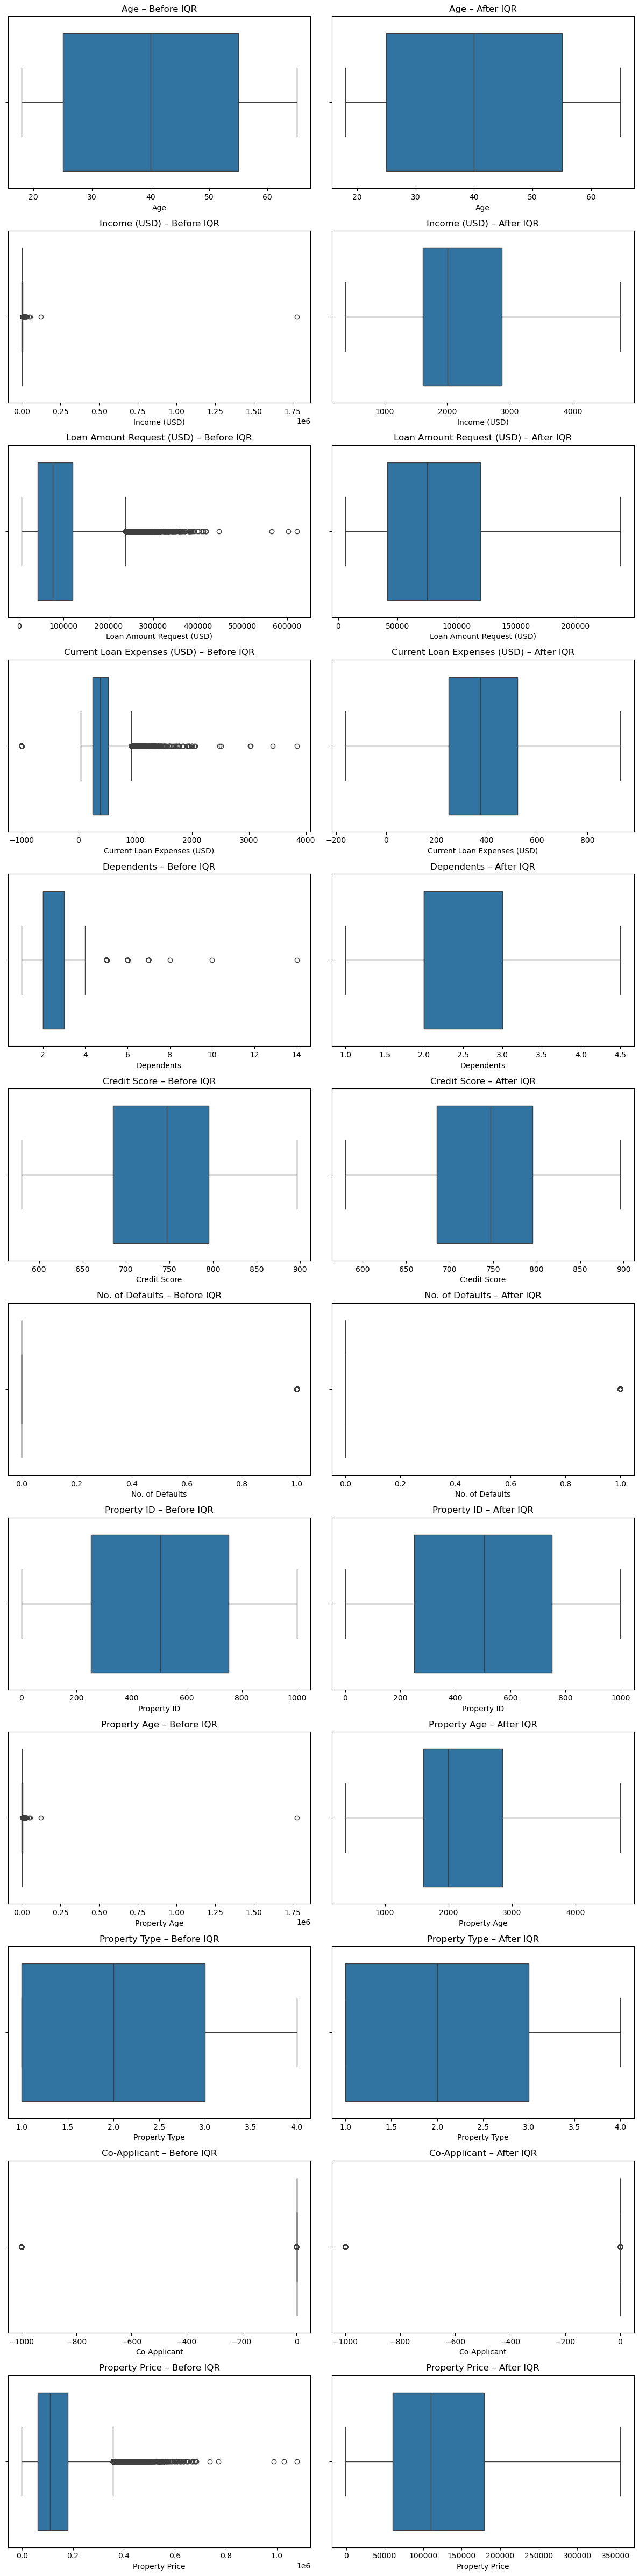

In [19]:
cols_to_plot = num_cols[:-1]  # adjust if needed

fig, axes = plt.subplots(len(cols_to_plot), 2, figsize=(12, 4 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=df_imputed[col], ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} – Before IQR")

    sns.boxplot(x=df_iqr[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} – After IQR")

plt.tight_layout()
plt.savefig( "assign3_6.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

In [20]:
df_iqr = df_iqr[df_iqr["Co-Applicant"] >= 0]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


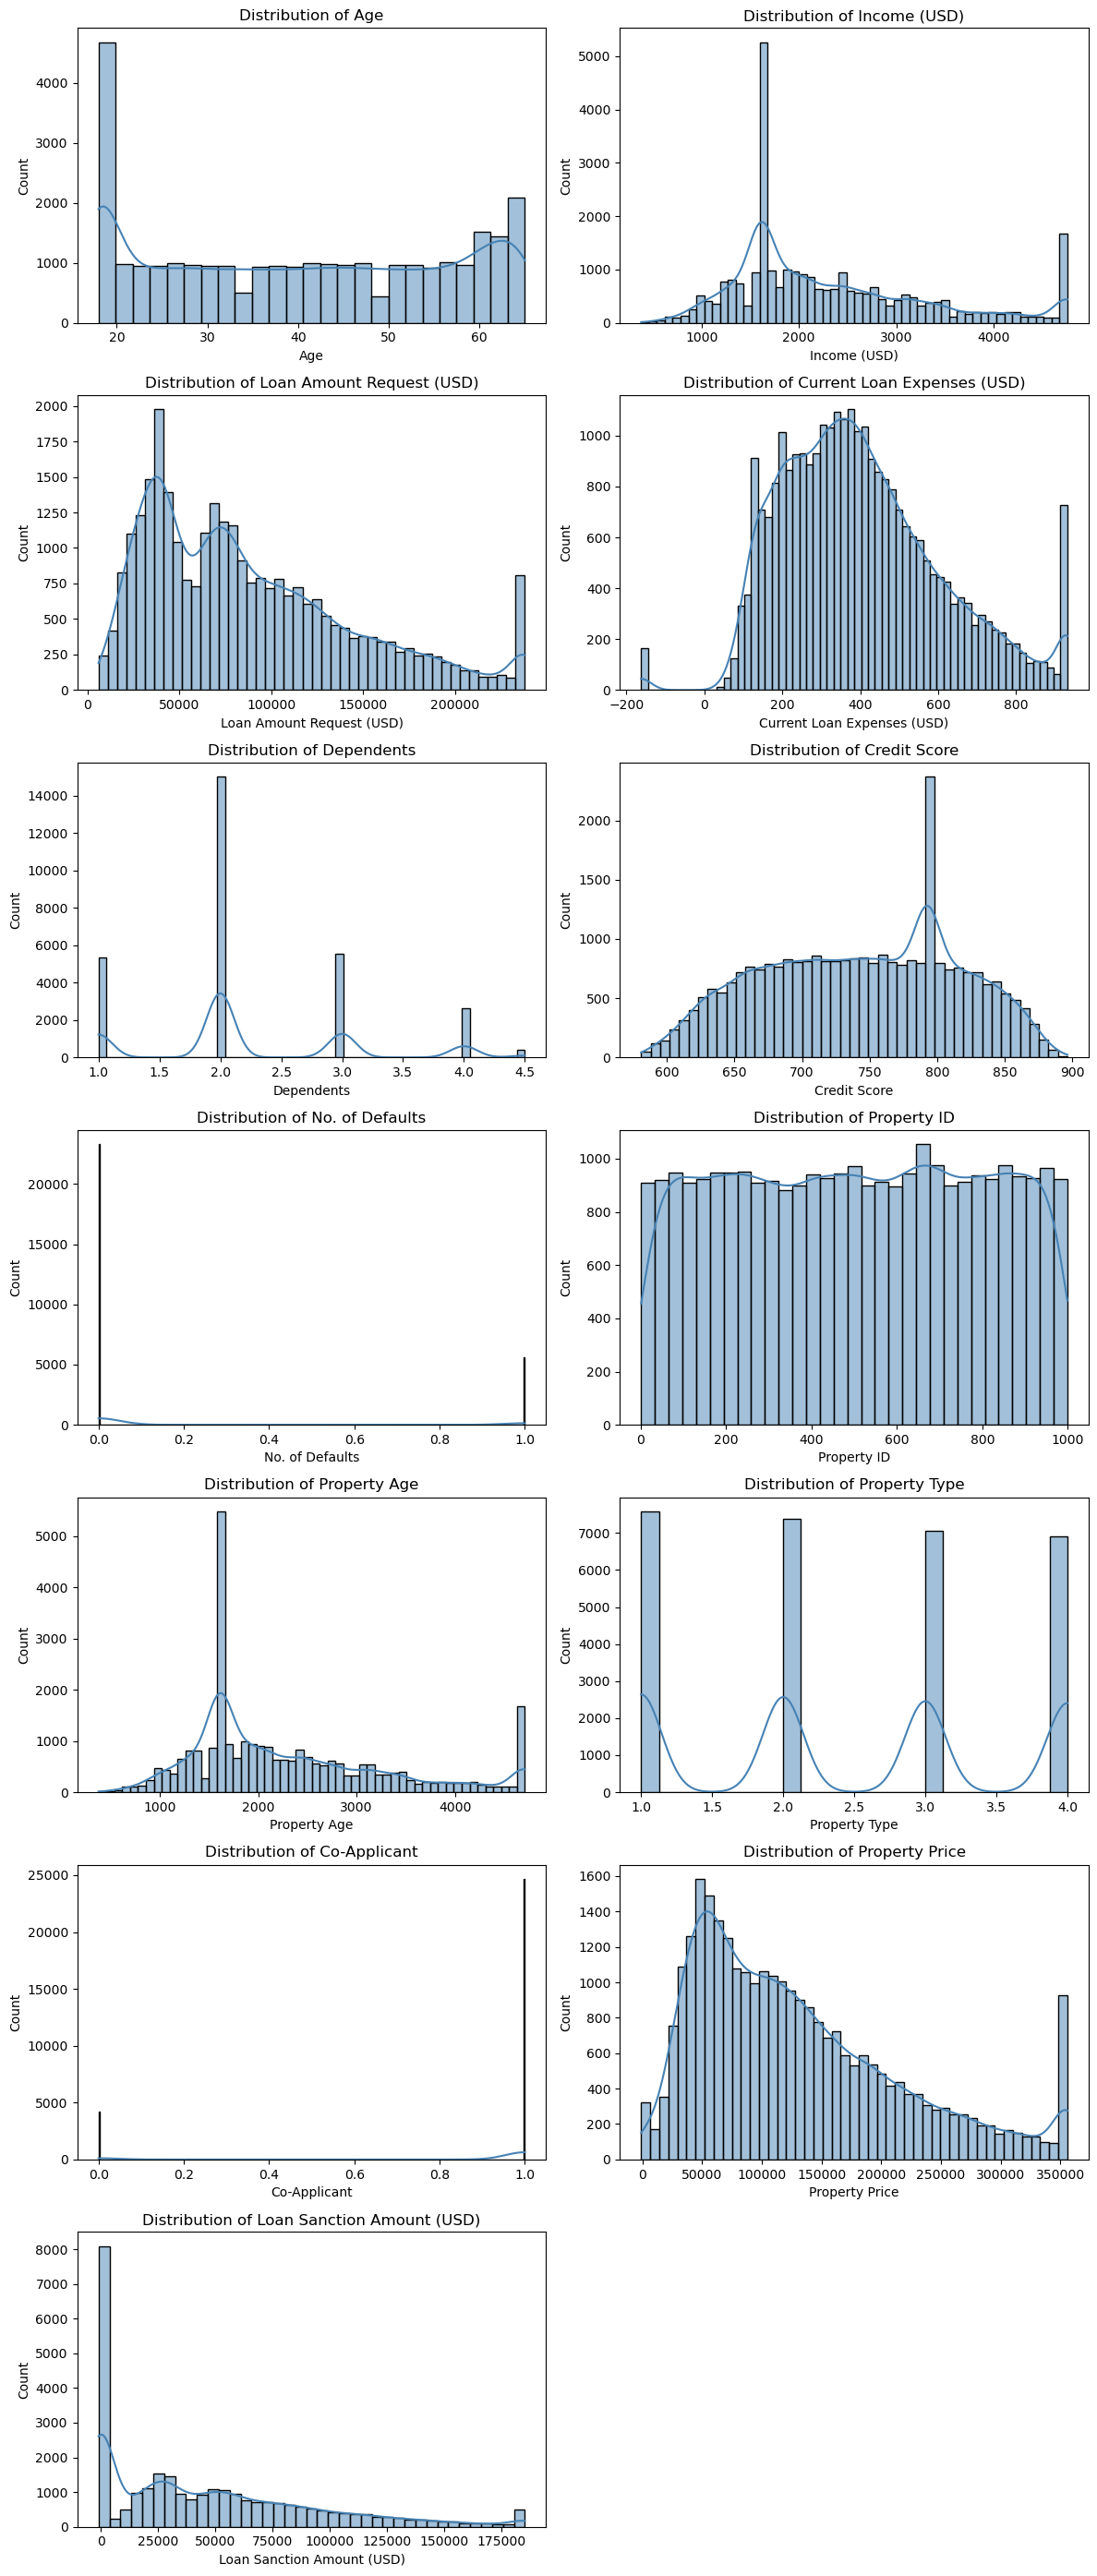

In [21]:
cols = 2
rows = (len(numeric_cols) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]
for i, col in enumerate(numeric_cols):
    sns.histplot(df_iqr[col], kde=True, ax=axes[i], color="steelblue", linewidth=1)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
# hide unused axes
for j in range(i+1, len(axes)):
    try:
        fig.delaxes(axes[j])
    except Exception:
        pass
plt.tight_layout()
plt.savefig( "assign3_7.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

In [22]:
#Encoding Categorical Columns using One-Hot encoder: 
#First Drop Unnecessary Columns
df_iqr.drop(['Customer ID', 'Property ID', 'Name'], axis=1, inplace=True)

In [23]:
cat_cols = df_iqr.select_dtypes(
    include=["object", "category", "string", "bool"]
).columns.tolist()

num_cols = df_iqr.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:")
print(cat_cols)

print("\nNumerical columns:")
print(num_cols)
df_encoded = pd.get_dummies(
    df_iqr,
    columns=cat_cols,
    drop_first=True   # IMPORTANT for linear models
)

print("Shape after One-Hot Encoding:", df_encoded.shape)
df_encoded.head()


Categorical columns:
['Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location']

Numerical columns:
['Age', 'Income (USD)', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']
Shape after One-Hot Encoding: (28935, 46)


,Age,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property Age,Property Type,Co-Applicant,...,Type of Employment_Security staff,Type of Employment_Waiters/barmen staff,Location_Semi-Urban,Location_Urban,Expense Type 1_Y,Expense Type 2_Y,Has Active Credit Card_Inactive,Has Active Credit Card_Unpossessed,Property Location_Semi-Urban,Property Location_Urban
0,56,1933.050,72809.58,241.08,3.0,809.44,0,1933.05,4,1,...,False,False,True,False,False,False,False,False,False,False
1,32,4759.605,46837.47,495.81,1.0,780.40,0,4710.53,2,1,...,False,False,True,False,False,True,False,True,False,False
2,65,988.190,45593.04,171.95,1.0,833.15,0,988.19,2,0,...,False,False,True,False,False,True,False,True,False,True
3,65,1608.430,80057.92,298.54,2.0,832.70,1,1608.43,2,1,...,False,False,False,False,False,True,False,True,True,False
4,31,2614.770,113858.89,491.41,2.0,745.55,1,2614.77,4,1,...,False,False,True,False,False,True,False,False,True,False


In [24]:
#Standardizing Numerical Values:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = df_encoded.copy()

df_scaled[num_cols] = scaler.fit_transform(df_encoded[num_cols])
print("Mean after scaling:")
print(df_scaled[num_cols].mean().round(4))

print("\nStandard deviation after scaling:")
print(df_scaled[num_cols].std(ddof=0).round(4))

Mean after scaling:
Age                           -0.0
Income (USD)                   0.0
Loan Amount Request (USD)      0.0
Current Loan Expenses (USD)    0.0
Dependents                    -0.0
Credit Score                   0.0
No. of Defaults                0.0
Property Age                   0.0
Property Type                 -0.0
Co-Applicant                  -0.0
Property Price                -0.0
Loan Sanction Amount (USD)     0.0
dtype: float64

Standard deviation after scaling:
Age                            1.0
Income (USD)                   1.0
Loan Amount Request (USD)      1.0
Current Loan Expenses (USD)    1.0
Dependents                     1.0
Credit Score                   1.0
No. of Defaults                1.0
Property Age                   1.0
Property Type                  1.0
Co-Applicant                   1.0
Property Price                 1.0
Loan Sanction Amount (USD)     1.0
dtype: float64


Numerical columns: ['Age', 'Income (USD)', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']
Categorical columns: ['Gender_M', 'Income Stability_Low', 'Profession_Commercial associate', 'Profession_Maternity leave', 'Profession_Pensioner', 'Profession_State servant', 'Profession_Student', 'Profession_Unemployed', 'Profession_Working', 'Type of Employment_Cleaning staff', 'Type of Employment_Cooking staff', 'Type of Employment_Core staff', 'Type of Employment_Drivers', 'Type of Employment_HR staff', 'Type of Employment_High skill tech staff', 'Type of Employment_IT staff', 'Type of Employment_Laborers', 'Type of Employment_Low-skill Laborers', 'Type of Employment_Managers', 'Type of Employment_Medicine staff', 'Type of Employment_Private service staff', 'Type of Employment_Realty agents', 'Type of Employment_Sales staff', 'Type of Em

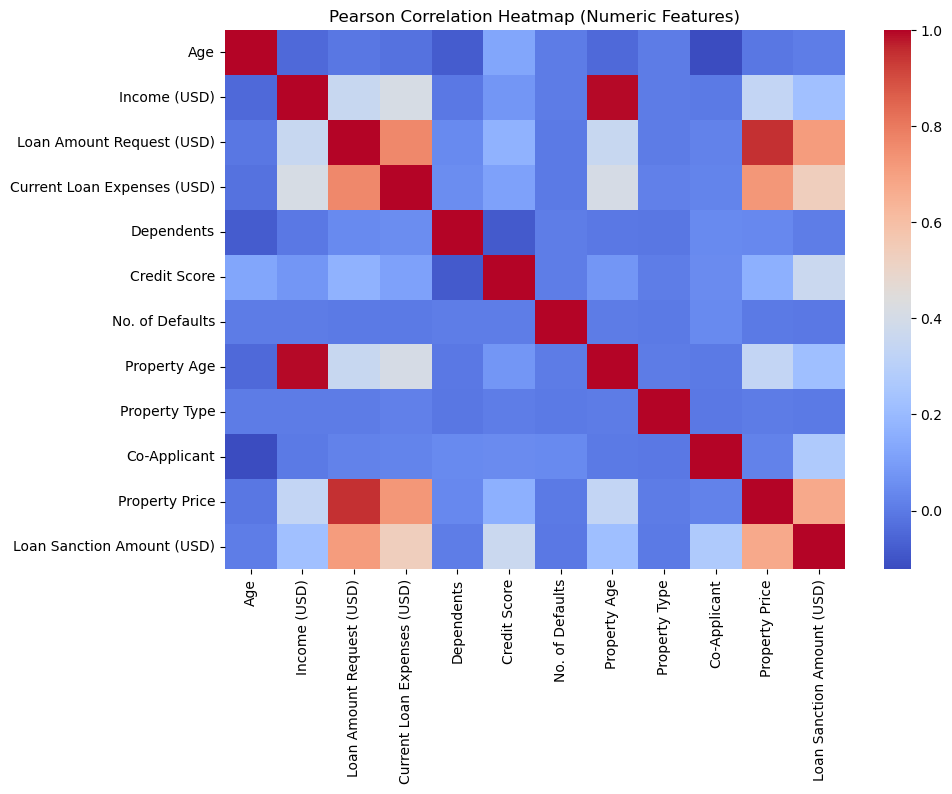

Likely target column (numeric): Loan Amount Request (USD)


In [25]:
#Feature Distribution And Target Distribution
num_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_scaled.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)
corr_matrix = df_scaled[num_cols].corr(method="pearson")

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Pearson Correlation Heatmap (Numeric Features)")
plt.savefig( "assign3_8.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()


avg_corr = corr_matrix.abs().mean().sort_values(ascending=False)
avg_corr
target_candidate = avg_corr.index[0]
print("Likely target column (numeric):", target_candidate)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


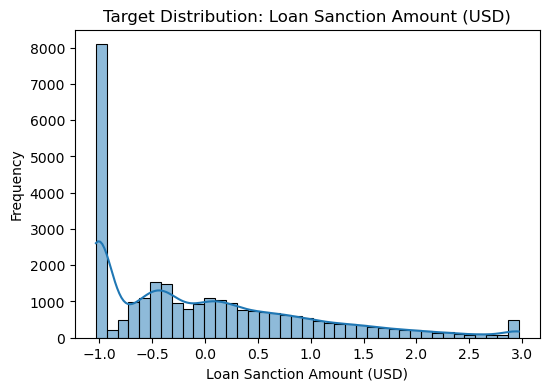

In [26]:
target_candidate = "Loan Sanction Amount (USD)"#This is the actual target candidate, seeming error in the execution
plt.figure(figsize=(6, 4))
sns.histplot(df_scaled[target_candidate], kde=True)
plt.title(f"Target Distribution: {target_candidate}")
plt.xlabel(target_candidate)
plt.ylabel("Frequency")
plt.savefig( "assign3_9.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()


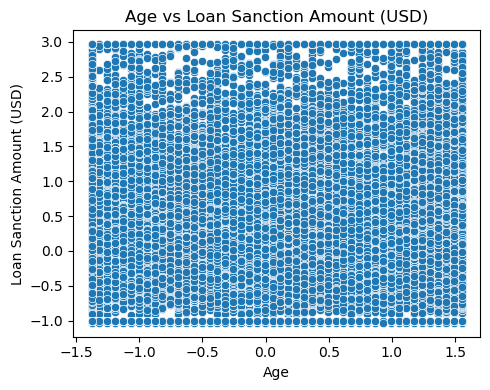

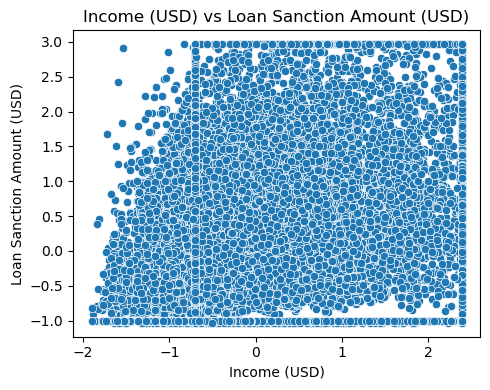

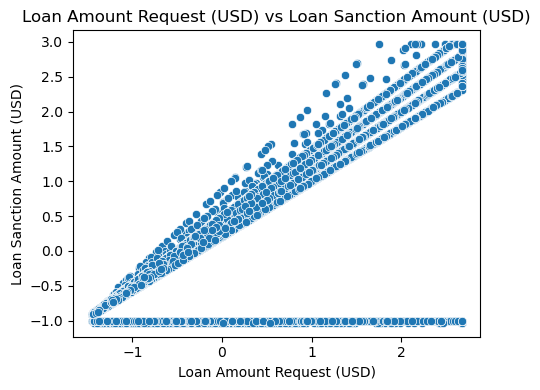

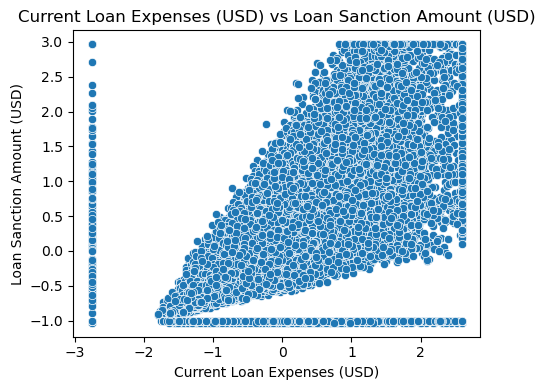

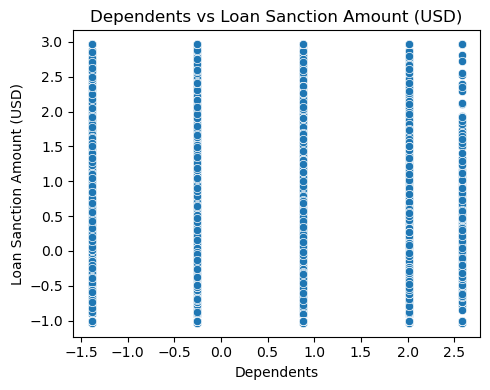

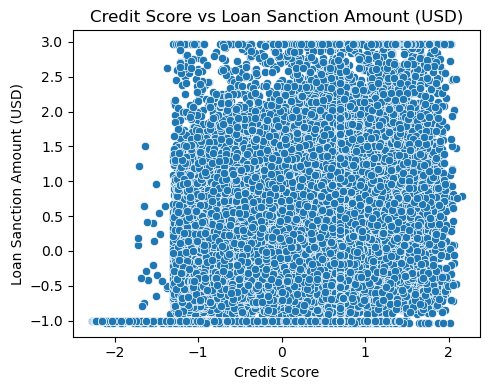

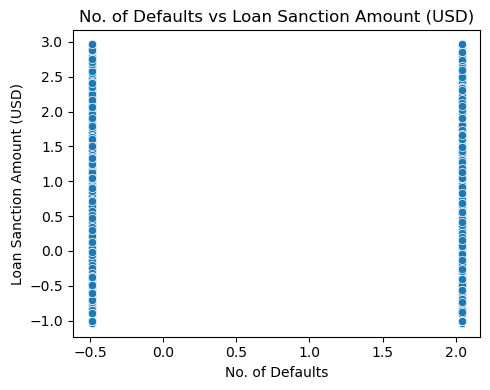

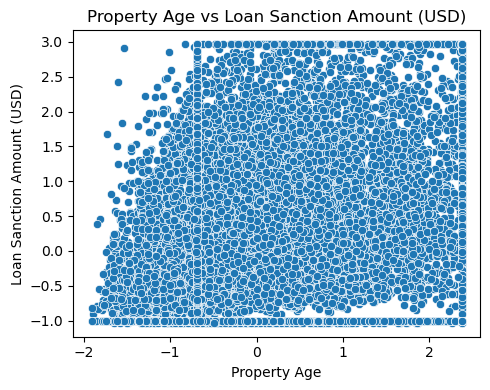

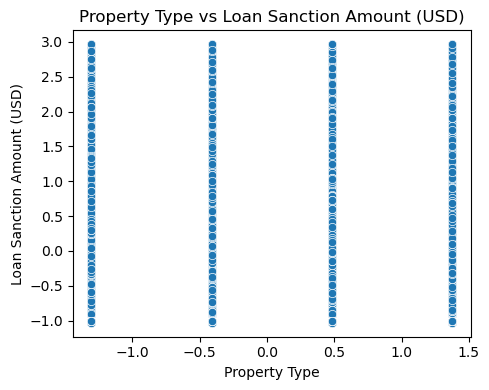

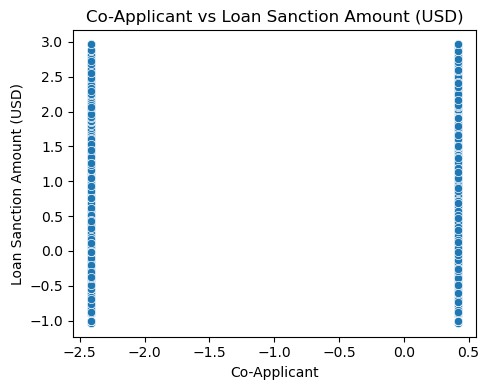

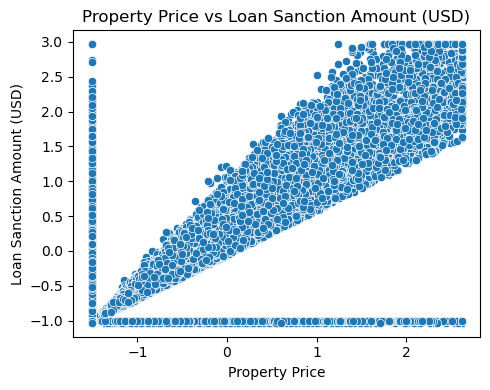

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

target = target_candidate

num_features = [col for col in num_cols if col != target]

for col in num_features:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=df_scaled[col], y=df_scaled[target])
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()
    plt.savefig( "assign3_10.eps", format="eps", dpi=600, bbox_inches="tight" )
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


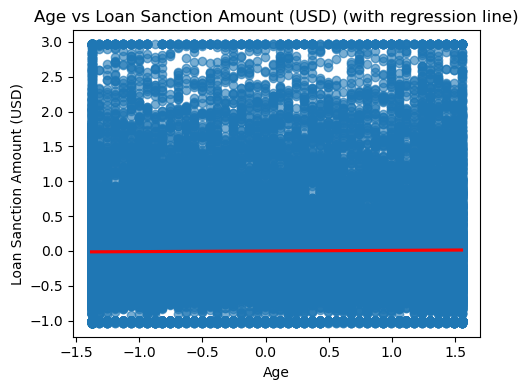

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


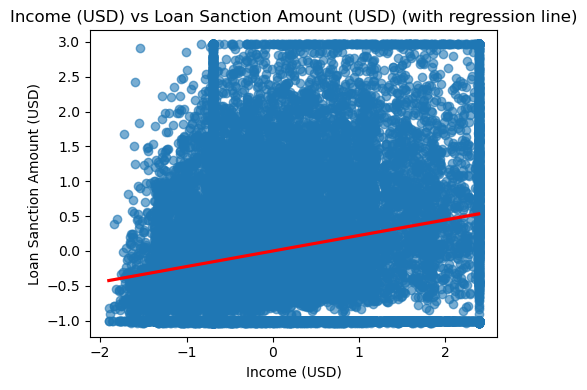

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


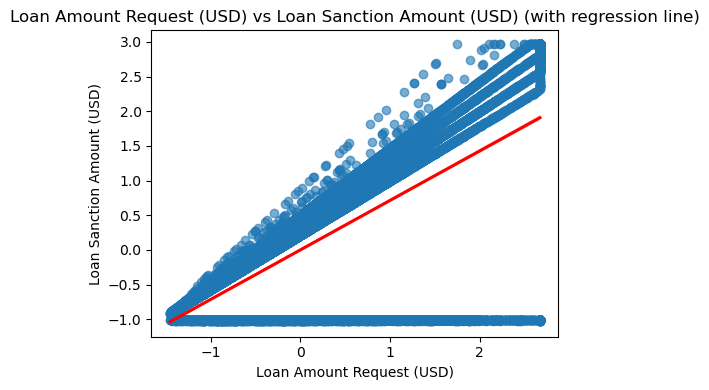

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


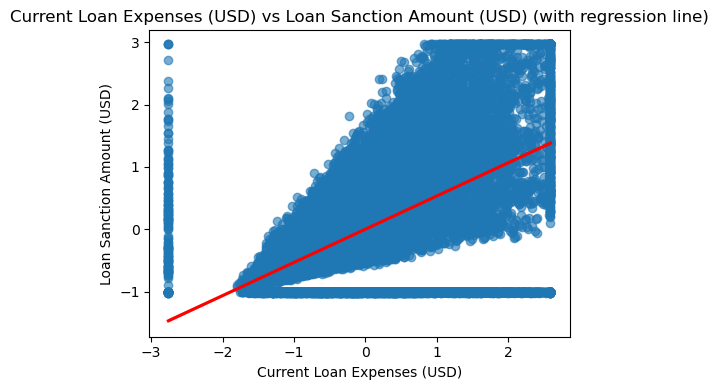

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


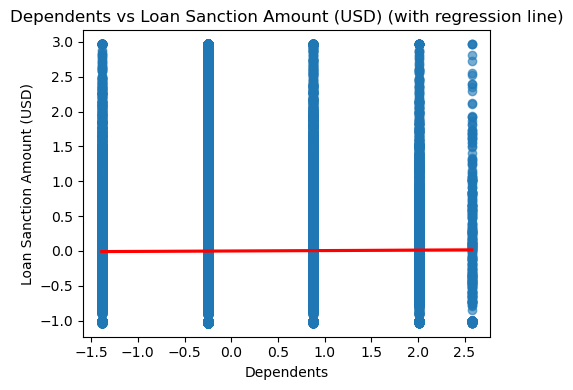

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


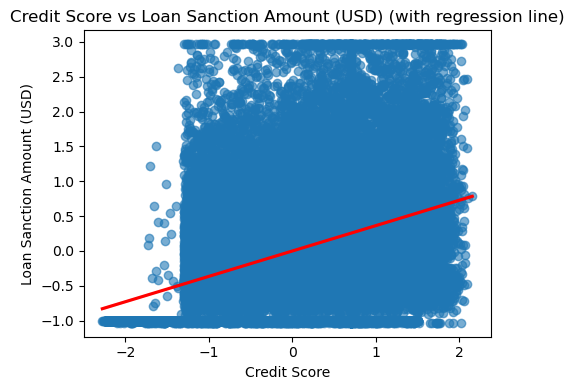

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


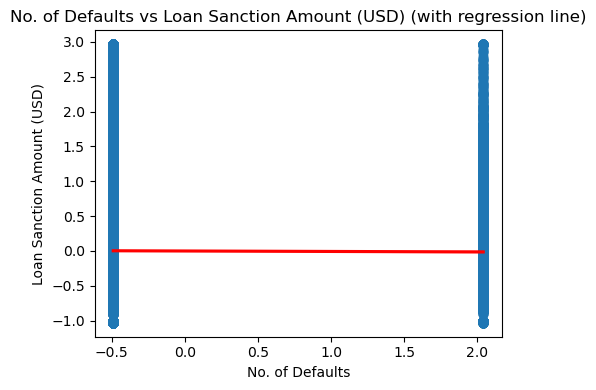

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


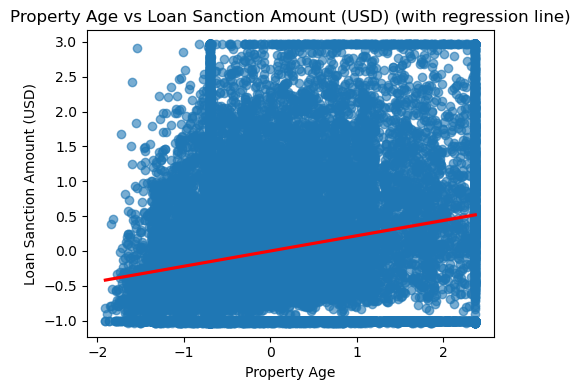

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


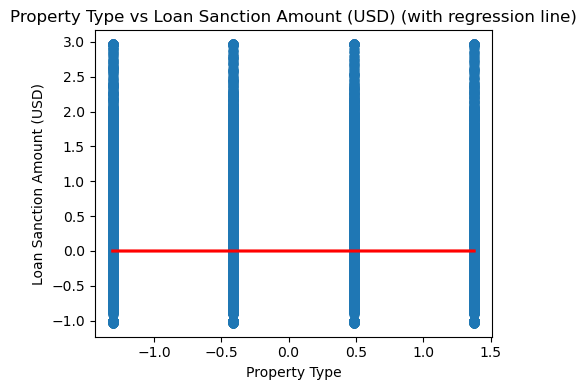

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


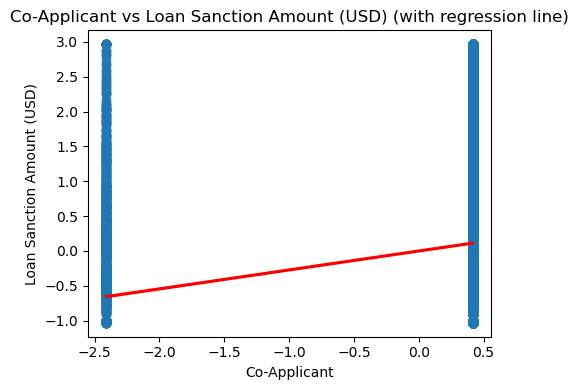

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


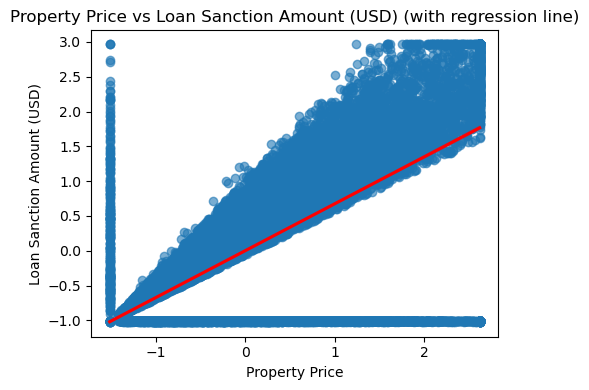

In [28]:
for col in num_features:
    plt.figure(figsize=(5, 4))
    sns.regplot(
        x=df_scaled[col],
        y=df_scaled[target],
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"}
    )
    plt.title(f"{col} vs {target} (with regression line)")
    plt.tight_layout()
    plt.savefig( "assign3_11.eps", format="eps", dpi=600, bbox_inches="tight" )
    plt.show()


In [29]:
#Property Price, Loan Amount Request, Current Loan Expenses show best linearity
#Split Into train and test data
from sklearn.model_selection import train_test_split
# Replace with your actual target column
target = target_candidate  

X = df_scaled.drop(columns=[target])
y = df_scaled[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


X shape: (28935, 45)
y shape: (28935,)


In [30]:
#Training Baseline Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
start=time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
takentime=time.time()-start
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)
print("TRAINING METRICS")
print("Time taken: ",takentime)
print("MSE :", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("R²  :", r2_score(y_train, y_train_pred))

TRAINING METRICS
Time taken:  0.1449897289276123
MSE : 0.36536672857823765
RMSE: 0.6044557292128495
MAE : 0.41523338022078976
R²  : 0.6331008611305569


In [31]:
print("\nTESTING METRICS")
print("MSE :", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("R²  :", r2_score(y_test, y_test_pred))


TESTING METRICS
MSE : 0.3623026764976118
RMSE: 0.6019158383840816
MAE : 0.41490760490720174
R²  : 0.643649485200277


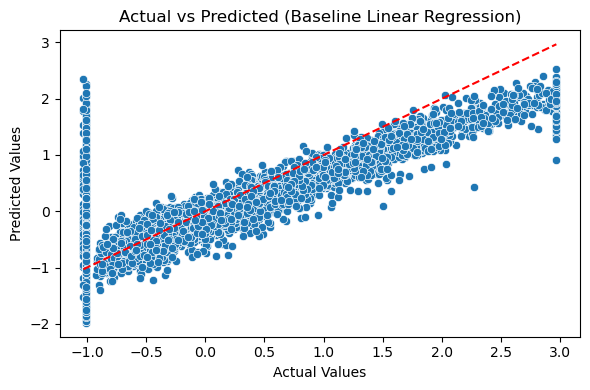

In [32]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

coefficients.head(10)
import matplotlib.pyplot as plt
import seaborn as sns

def actual_vs_predicted(y_test, y_pred, title):
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linestyle="--"
    )
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(title)
    plt.tight_layout()
    plt.savefig("assign3_12.eps", format="eps", dpi=600, bbox_inches="tight" )
    plt.show()

actual_vs_predicted(y_test,y_test_pred,"Actual vs Predicted (Baseline Linear Regression)");
def get_coef_vector(model):
    if not hasattr(model, "coef_"):
        return None
    coef = model.coef_
    coef = np.asarray(coef)
    if coef.ndim == 2:  # SVR linear -> (1, n_features)
        coef = coef.ravel()
    return coef
def inspect_coefficients(model, feature_names, top_n=10):
    coef = get_coef_vector(model)
    if coef is None:
        return pd.DataFrame({"Feature": [], "Coefficient": []})

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coef
    }).sort_values(by="Coefficient", key=lambda s: s.abs(), ascending=False)

    return coef_df.head(top_n)


In [33]:
#RIDGE REGRESSION
ridge = Ridge()
#Grid Search
ridge_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid_search = GridSearchCV(
    ridge,
    ridge_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid_search.fit(X_train, y_train)
#Random Search
ridge_random = RandomizedSearchCV(
    ridge,
    {"alpha": np.logspace(-2, 3, 100)},
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

ridge_random.fit(X_train, y_train)
grid_time = ridge_grid_search.refit_time_
random_time = ridge_random.refit_time_
best_ridge_grid = ridge_grid_search.best_estimator_
best_ridge_random = ridge_random.best_estimator_
print("Best Ridge Parameters(Grid): ",best_ridge_grid)
print("Best CV R2:",ridge_grid_search.best_score_)
print("Best Refit time: ",grid_time)
print("Best Ridge Parameters(Random): ",best_ridge_random)
print("Best CV R2:",ridge_random.best_score_)
print("Best Refit time: ",random_time)

Best Ridge Parameters(Grid):  Ridge(alpha=10)
Best CV R2: 0.6316839649902994
Best Refit time:  0.03245377540588379
Best Ridge Parameters(Random):  Ridge(alpha=np.float64(34.30469286314919))
Best CV R2: 0.6316879564345499
Best Refit time:  0.039270639419555664


RIDGE METRICS
Test METRICS
Time taken:  0.03289031982421875
MSE : 0.3623615794811136
RMSE: 0.6019647659797985
MAE : 0.41495460128655126
R²  : 0.6435915499161742


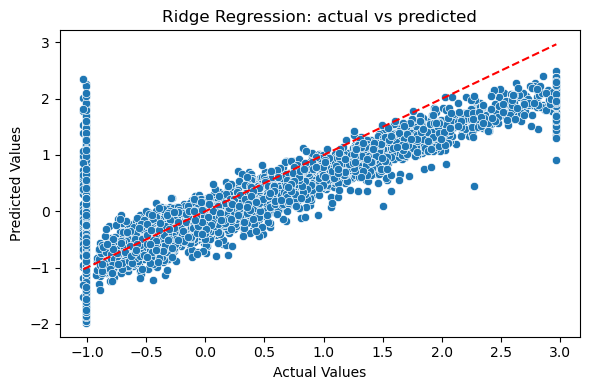

,Feature,Coefficient
2,Loan Amount Request (USD),0.702452
15,Profession_Pensioner,0.270449
9,Co-Applicant,0.260225
5,Credit Score,0.217431
12,Income Stability_Low,0.157522
7,Property Age,-0.150032
1,Income (USD),0.115095
19,Profession_Working,-0.092693
34,Type of Employment_Secretaries,0.081418
13,Profession_Commercial associate,-0.080511


In [34]:

print("RIDGE METRICS")
start=time.time()
best_ridge_grid.fit(X_train, y_train)
takentime=time.time()-start
y_train_pred = best_ridge_grid.predict(X_train)
y_test_pred = best_ridge_grid.predict(X_test)
print("Test METRICS")
print("Time taken: ",takentime)
print("MSE :", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("R²  :", r2_score(y_test, y_test_pred))

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: actual vs predicted")
plt.tight_layout()
plt.savefig("assign3_13.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

inspect_coefficients(best_ridge_grid, X_train.columns)


In [35]:
#LASSO REGRESSION
lasso = Lasso(max_iter=10000)

lasso_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid_search = GridSearchCV(
    lasso,
    lasso_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid_search.fit(X_train, y_train)
#Random Search
lasso_random = RandomizedSearchCV(
    lasso,
    {"alpha": np.logspace(-3, 1, 10)},
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

lasso_random.fit(X_train, y_train)
grid_time = lasso_grid_search.refit_time_
random_time = lasso_random.refit_time_
best_lasso_grid = lasso_grid_search.best_estimator_
best_lasso_random = lasso_random.best_estimator_
print("Best Lasso Parameters(Grid): ",best_lasso_grid)
print("Best CV R2:",lasso_grid_search.best_score_)
print("Best Refit time: ",grid_time)
print("Best Ridge Parameters(Random): ",best_lasso_random)
print("Best CV R2:",lasso_random.best_score_)
print("Best Refit time: ",random_time)

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=20. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Lasso Parameters(Grid):  Lasso(alpha=0.001, max_iter=10000)
Best CV R2: 0.6316673147329555
Best Refit time:  3.3817970752716064
Best Ridge Parameters(Random):  Lasso(alpha=np.float64(0.001), max_iter=10000)
Best CV R2: 0.6316673147329555
Best Refit time:  3.168980360031128


LASSO METRICS
TRAINING METRICS
Time taken:  2.742649555206299
MSE : 0.3628894502297919
RMSE: 0.6024030629319475
MAE : 0.4152491129648494
R²  : 0.6430723513972516


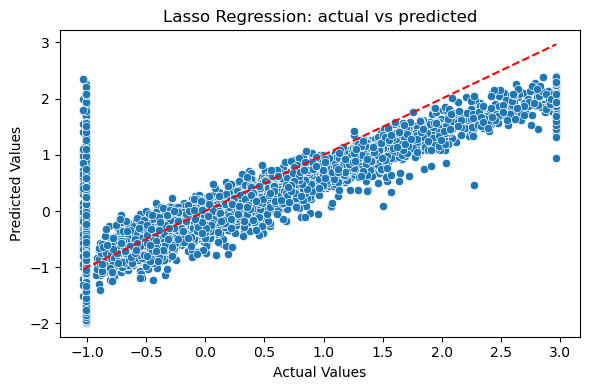

,Feature,Coefficient
2,Loan Amount Request (USD),0.683370
9,Co-Applicant,0.258592
5,Credit Score,0.220091
15,Profession_Pensioner,0.177487
29,Type of Employment_Managers,0.051933
7,Property Age,-0.039580
40,Expense Type 2_Y,0.021792
6,No. of Defaults,-0.018078
19,Profession_Working,-0.014387
11,Gender_M,-0.013909


In [36]:
#Best = random

print("LASSO METRICS")
start=time.time()
best_lasso_random.fit(X_train, y_train)
takentime=time.time()-start
y_train_pred = best_lasso_random.predict(X_train)
y_test_pred = best_lasso_random.predict(X_test)
print("TRAINING METRICS")
print("Time taken: ",takentime)
print("MSE :", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("R²  :", r2_score(y_test, y_test_pred))

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso Regression: actual vs predicted")
plt.tight_layout()
plt.savefig("assign3_14.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

inspect_coefficients(best_lasso_random, X_train.columns)


In [37]:
#Elastic Search
#Grid
elastic = ElasticNet(max_iter=10000)

elastic_grid = {
    "alpha": [0.01, 0.1, 1,10],
    "l1_ratio": [0.2, 0.5, 0.8]
}

elastic_grid_search = GridSearchCV(
    elastic,
    elastic_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

elastic_grid_search.fit(X_train, y_train)
elastic_random = RandomizedSearchCV(
    elastic,
    {
        "alpha": np.logspace(-2, 1, 10),
        "l1_ratio": np.linspace(0.2,0.8,9)
    },
    n_iter=25,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

elastic_random.fit(X_train, y_train)
grid_time = elastic_grid_search.refit_time_
random_time = elastic_random.refit_time_
best_elastic_grid = elastic_grid_search.best_estimator_
best_elastic_random = elastic_random.best_estimator_
print("Best Elastic Net Parameters(Grid): ",best_elastic_grid)
print("Best CV R2:",elastic_grid_search.best_score_)
print("Best Refit time: ",grid_time)
print("Best Ridge Parameters(Random): ",best_elastic_random)
print("Best CV R2:",elastic_random.best_score_)
print("Best Refit time: ",random_time)

Best Elastic Net Parameters(Grid):  ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=10000)
Best CV R2: 0.6311869953341394
Best Refit time:  0.6933708190917969
Best Ridge Parameters(Random):  ElasticNet(alpha=np.float64(0.01), l1_ratio=np.float64(0.2), max_iter=10000)
Best CV R2: 0.6311869953341394
Best Refit time:  0.868476390838623


ELASTIC NET METRICS
TRAINING METRICS
Time taken:  1.0697441101074219
MSE : 0.3636396830263638
RMSE: 0.6030254414420372
MAE : 0.4162370277587317
R²  : 0.6423344439496377


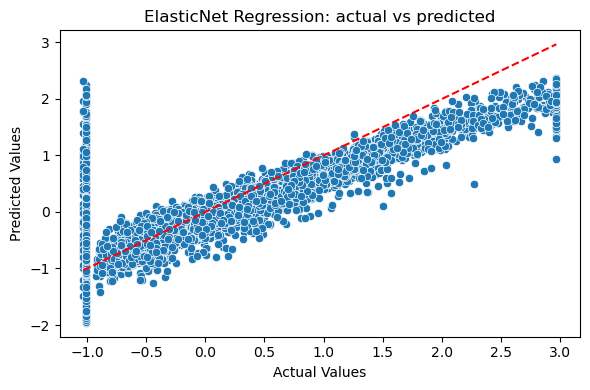

,Feature,Coefficient
2,Loan Amount Request (USD),0.646513
9,Co-Applicant,0.253734
5,Credit Score,0.221885
15,Profession_Pensioner,0.134893
29,Type of Employment_Managers,0.032795
7,Property Age,-0.030804
10,Property Price,0.026239
6,No. of Defaults,-0.016817
40,Expense Type 2_Y,0.016592
19,Profession_Working,-0.016589


In [38]:
print("ELASTIC NET METRICS")
start=time.time()
best_elastic_random.fit(X_train, y_train)
takentime=time.time()-start
y_train_pred = best_elastic_random.predict(X_train)
y_test_pred = best_elastic_random.predict(X_test)
print("TRAINING METRICS")
print("Time taken: ",takentime)
print("MSE :", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("R²  :", r2_score(y_test, y_test_pred))

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("ElasticNet Regression: actual vs predicted")
plt.tight_layout()
plt.savefig("assign3_15.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

inspect_coefficients(best_elastic_random, X_train.columns)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


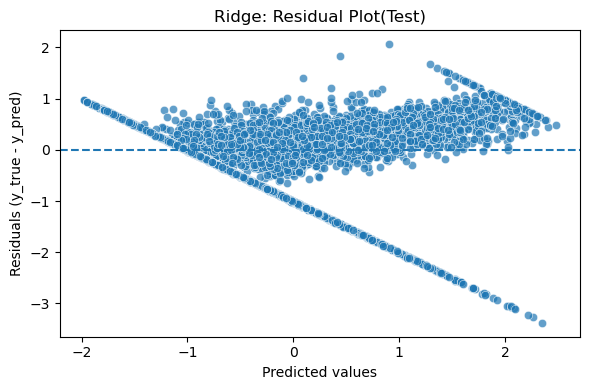

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


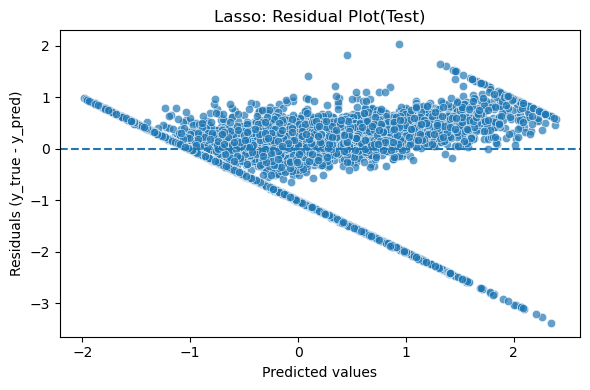

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


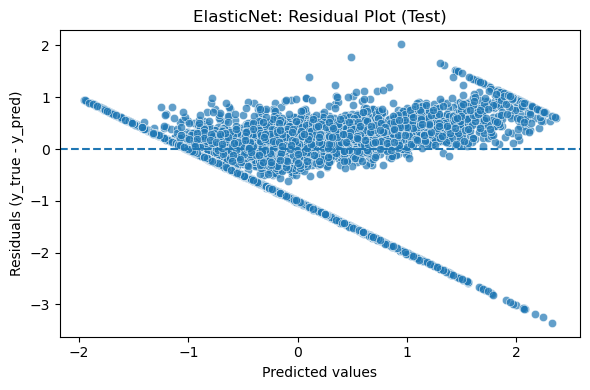

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


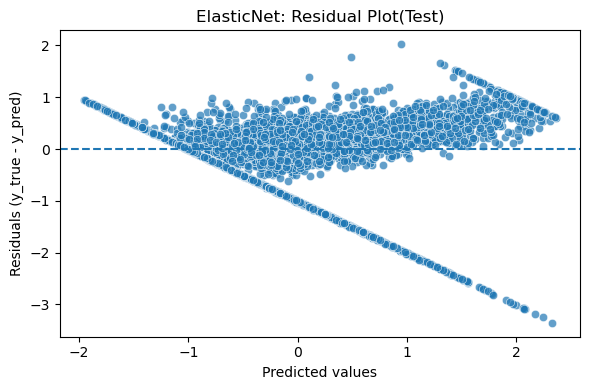

In [39]:
#RESIDUAL PLOTS:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def residual_plot(model, X, y, title="Residual Plot"):
    y_pred = model.predict(X)
    residuals = y - y_pred

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals (y_true - y_pred)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{title}.eps", format="eps", dpi=600, bbox_inches="tight" )
    plt.show()

# Example usage (after training):
y_pred = best_ridge_grid.predict(X_test)
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Ridge: Residual Plot(Test)")
plt.tight_layout()
plt.savefig("assign3_16.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()
y_pred =best_lasso_random.predict(X_test)
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Lasso: Residual Plot(Test)")
plt.tight_layout()
plt.savefig("assign3_17.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()
residual_plot(best_elastic_random, X_test, y_test, "ElasticNet: Residual Plot (Test)")
y_pred =best_elastic_random.predict(X_test)
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("ElasticNet: Residual Plot(Test)")
plt.tight_layout()
plt.savefig("assign3_18.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


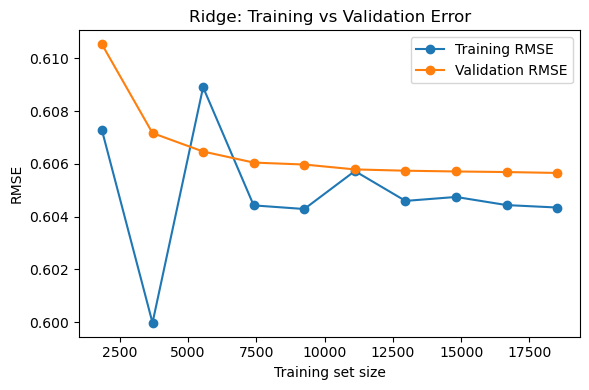

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


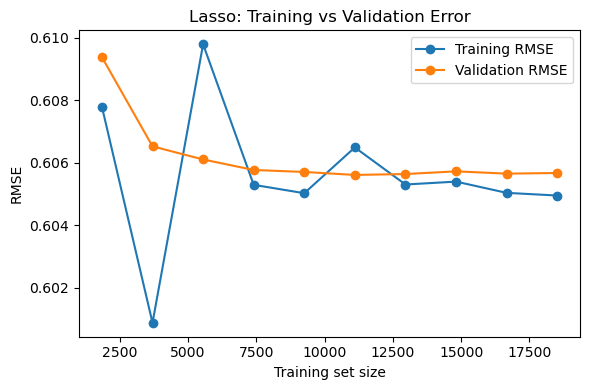

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


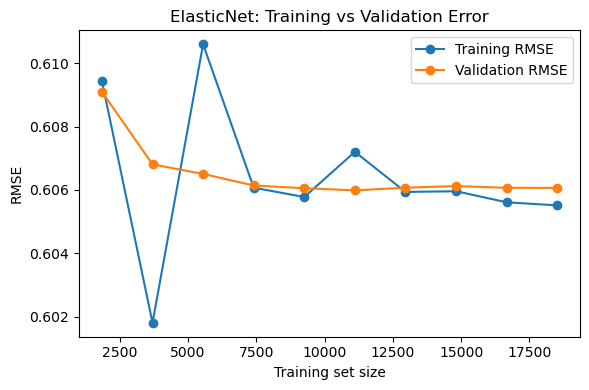

In [40]:
#Training error vs Validation error
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_ridge_grid,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse   = np.sqrt(-val_scores.mean(axis=1))

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_rmse, marker="o", label="Training RMSE")
plt.plot(train_sizes, val_rmse, marker="o", label="Validation RMSE")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Ridge: Training vs Validation Error")
plt.legend()
plt.tight_layout()
plt.savefig("assign3_19.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_lasso_random,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse   = np.sqrt(-val_scores.mean(axis=1))
plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_rmse, marker="o", label="Training RMSE")
plt.plot(train_sizes, val_rmse, marker="o", label="Validation RMSE")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Lasso: Training vs Validation Error")
plt.legend()
plt.tight_layout()
plt.savefig("assign3_20.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_elastic_random,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse   = np.sqrt(-val_scores.mean(axis=1))
plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_rmse, marker="o", label="Training RMSE")
plt.plot(train_sizes, val_rmse, marker="o", label="Validation RMSE")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("ElasticNet: Training vs Validation Error")
plt.legend()
plt.tight_layout()
plt.savefig("assign3_21.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


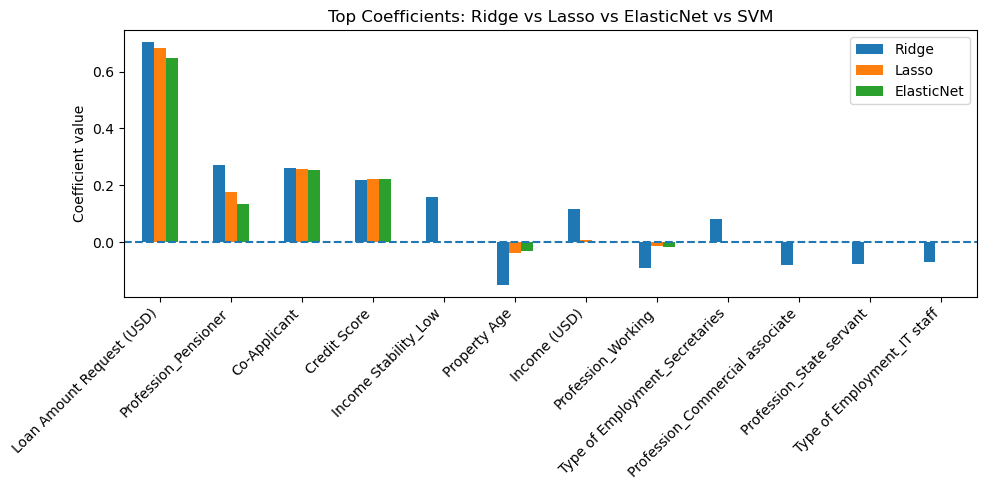

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def coefficient_comparison_barplot(models_dict, feature_names, top_n=12, title="Coefficient Comparison"):
    coef_df = pd.DataFrame(index=feature_names)

    for name, model in models_dict.items():
        coef = get_coef_vector(model)
        if coef is None:
            continue
        coef_df[name] = coef

    if coef_df.shape[1] == 0:
        print("No models with coefficients available to compare.")
        return

    top_features = coef_df.abs().max(axis=1).sort_values(ascending=False).head(top_n).index
    plot_df = coef_df.loc[top_features]

    ax = plot_df.plot(kind="bar", figsize=(10, 5))
    ax.axhline(0, linestyle="--")
    plt.title(title)
    plt.ylabel("Coefficient value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("assign3_22.eps", format="eps", dpi=600, bbox_inches="tight" )
    plt.show()

models_to_compare = {
    "Ridge": best_ridge_grid,
    "Lasso": best_lasso_random,
    "ElasticNet": best_elastic_random,
}

coefficient_comparison_barplot(
    models_to_compare,
    feature_names=X_train.columns,
    top_n=12,
    title="Top Coefficients: Ridge vs Lasso vs ElasticNet vs SVM"
)


In [42]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
models = {
    "Linear Regrerssion": lr,
    "Ridge": Ridge(**ridge_grid_search.best_params_),
    "Lasso": Lasso(**lasso_grid_search.best_params_, max_iter=10000),
    "ElasticNet": ElasticNet(**elastic_grid_search.best_params_, max_iter=10000)
}
cv_results = []

scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "r2": "r2"
}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    mae  = -scores["test_mae"].mean()
    mse  = -scores["test_mse"].mean()
    rmse = np.sqrt(mse)
    r2   = scores["test_r2"].mean()

    cv_results.append([name, mae, mse, rmse, r2])

cv_table = pd.DataFrame(
    cv_results,
    columns=["Model", "MAE", "MSE", "RMSE", "R^2"]
)

print("\nTable 2: Cross-Validation Performance\n")
print(cv_table.to_string(index=False))



Table 2: Cross-Validation Performance

             Model      MAE      MSE     RMSE      R^2
Linear Regrerssion 0.416162 0.366887 0.605712 0.631618
             Ridge 0.416061 0.366820 0.605657 0.631684
             Lasso 0.415567 0.366837 0.605670 0.631667
        ElasticNet 0.416212 0.367312 0.606063 0.631187


In [43]:
test_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    test_results.append([name, mae, mse, rmse, r2])

test_table = pd.DataFrame(
    test_results,
    columns=["Model", "MAE", "MSE", "RMSE", "R^2"]
)

print("\nTable 3: Test Set Performance\n")
print(test_table.to_string(index=False))



Table 3: Test Set Performance

             Model      MAE      MSE     RMSE      R^2
Linear Regrerssion 0.414908 0.362303 0.601916 0.643649
             Ridge 0.414955 0.362362 0.601965 0.643592
             Lasso 0.415249 0.362889 0.602403 0.643072
        ElasticNet 0.416237 0.363640 0.603025 0.642334


In [44]:
if hasattr(X_train, "columns"):
    feature_names = list(X_train.columns)
else:
    feature_names = [f"Feature {i+1}" for i in range(X_train.shape[1])]
coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Linear": lr.coef_,
    "Ridge": best_ridge_grid.coef_,
    "Lasso": best_lasso_random.coef_,
    "Elastic Net": best_elastic_random.coef_
})

# Optional: show only top features (by Linear magnitude) if too many columns
top_k = min(10, len(feature_names))  # change 10 to 3 if you want exactly like screenshot
coef_table_top = coef_table.copy()
coef_table_top["abs_lin"] = np.abs(coef_table_top["Linear"])
coef_table_top = coef_table_top.sort_values("abs_lin", ascending=False).head(top_k).drop(columns=["abs_lin"])

print("\nTable 4: Coefficient Comparison (Top Features)\n")
print(coef_table_top.to_string(index=False))


Table 4: Coefficient Comparison (Top Features)

                        Feature    Linear     Ridge     Lasso  Elastic Net
      Loan Amount Request (USD)  0.706007  0.702452  0.683370     0.646513
             Profession_Student -0.535421 -0.040355 -0.000000    -0.000000
     Profession_Maternity leave -0.280711 -0.017549 -0.000000    -0.000000
                   Co-Applicant  0.260458  0.260225  0.258592     0.253734
                   Credit Score  0.217272  0.217431  0.220091     0.221885
           Profession_Pensioner  0.214109  0.270449  0.177487     0.134893
           Income Stability_Low  0.191994  0.157522  0.000000    -0.000000
             Profession_Working -0.183600 -0.092693 -0.014387    -0.016589
Profession_Commercial associate -0.171515 -0.080511 -0.000000    -0.000000
       Profession_State servant -0.168093 -0.076703  0.000000     0.000000


In [45]:
#IN THIS PROBLEM, WE CAN SEE THAT Ridge regression seems to be the best model.
print("Ridge Mean Accuracy:", cv_scores["Ridge"].mean())
print("Lasso  Mean Accuracy:", cv_scores["Lasso"].mean())
print("ElasticNet NB Mean Accuracy:", cv_scores["ElasticNet"].mean())
print("SVR Linear Mean Accuracy:", cv_scores["SVR_Linear"].mean())

NameError: name 'cv_scores' is not defined